In [29]:
import gymnasium as gym
import humanoid_bench
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import xgboost as xgb
import imageio

In [37]:
env = gym.make('h1hand-crawl-v0')
# env = gym.make('h1hand-walk-v0')
print(env.action_space)
print(env.observation_space)

Box(-1.0, 1.0, (61,), float32)
Box(-inf, inf, (151,), float64)


(1700, 61)
(1700, 151)


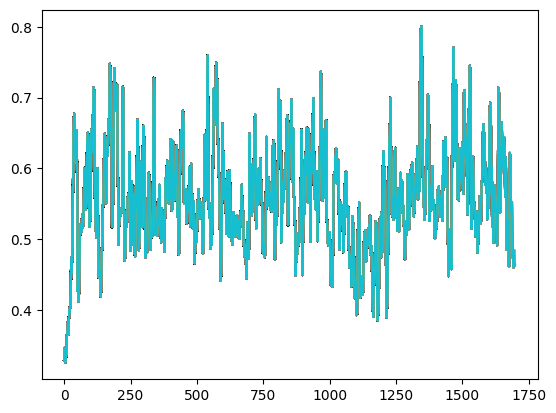

In [35]:
max_step = 1700
iters = 1
OBS = []
ACTIONS = []
REWARDS = []
TIMES = []

for ite in range(iters):
    observation, info = env.reset(seed=9515+ite)
    env.action_space.seed(515+ite)
    actions = []
    observations = []
    rewards = []
    times = []
    for step in range(1,max_step+1):
        action = env.action_space.sample()
        # action = np.zeros(env.action_space.shape, dtype=np.float32) ## test with action = 0
        observation, reward, terminated, truncated, info = env.step(action)
        # done = terminated or truncated
        # if done:
        #     # print(step)
        #     break
        actions.append(action)
        observations.append(observation)
        rewards.append(reward)
        times.append(step)
        plt.plot(range(step),rewards)

    ACTIONS.append(actions)
    OBS.append(observations)
    REWARDS.append(np.array(rewards).reshape(-1,1))
    TIMES.append(np.array(times).reshape(-1,1))
ACTIONS_arr =  np.vstack(ACTIONS)
OBS_arr =  np.vstack(OBS)
REWARDS_arr =  np.vstack(REWARDS)
TIMES_arr =  np.vstack(TIMES)
print(ACTIONS_arr.shape)
print(OBS_arr.shape)
    

In [38]:
obs, info = env.reset(seed=9515)
# print(obs)
frames = []
frames.append(env.render())   # frame at t=0

T = ACTIONS_arr.shape[0]
# T = 250
for t in range(T):
    action = ACTIONS_arr[t]
    obs, reward, terminated, truncated, info = env.step(action)
    frames.append(env.render())
    if terminated or truncated:
        break
# env.close()
imageio.mimsave("humanoid_walk_warmup_envseed9515.gif", frames, fps=30)

In [11]:
max(REWARDS_arr)

array([0.813039])